
# Factory Optimization Engine

## Business Goal

This notebook uses the trained machine learning model to support factory allocation decisions.

The goal is to estimate business performance under different factory or operational scenarios and recommend decisionns that improve profitability while efficient supply chain planning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
data_path = Path("../data/processed")
model_path = Path("../models")

df = pd.read_csv(data_path / "factory_sales_feature_engineered.csv")

model = joblib.load(model_path / "gradient_boosting_model.pkl")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
print("Model loaded successfully")

Dataset loaded successfully
Dataset shape: (10194, 30)
Model loaded successfully


## Factory Scenario Preparation

To evaluate factory allocation decisions, the dataset must be prepared into the same feature format used during model training.

This step selects business-relevant variables and converts categorical columns into numerical format so the trained model can generate profit predictions.

In [18]:
# Use exactly the same features the saved model was trained on

model_features = list(model.feature_names_in_)

X_encoded = pd.get_dummies(
    df,
    columns=["Ship Mode", "Region", "Sales Category"],
    drop_first=True
)

X_encoded = X_encoded.reindex(columns=model_features, fill_value=0)

print("Scenario feature matrix shape:", X_encoded.shape)
X_encoded.head()

Scenario feature matrix shape: (10194, 15)


,Sales,Units,High Value Order,Order Year,Order Month,Order Quarter,Is Weekend,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Region_Gulf,Region_Interior,Region_Pacific,Sales Category_Low,Sales Category_Medium
0,6.50,2,0,2024,1,1,0,False,False,True,False,True,False,True,False
1,7.50,2,0,2024,1,1,0,False,False,True,False,True,False,True,False
2,10.47,3,0,2024,1,1,0,False,False,True,False,True,False,False,True
3,10.80,3,0,2024,1,1,0,False,False,True,False,True,False,False,True
4,11.25,3,0,2024,1,1,0,False,False,True,False,False,False,False,True


## Profit Prediction

The trained Gradient Boosting model estimates the expected Gross Profit for every order.

These predictions represent the expected business outcome under the current allocation strategy and will later be used to compare optimization scenarios.

In [19]:
# Generate predicted profit

predicted_profit = model.predict(X_encoded)

df["Predicted Profit"] = predicted_profit

print("Predictions generated successfully.")
print()

print(df[[
    "Sales",
    "Cost",
    "Region",
    "Ship Mode",
    "Predicted Profit"
]].head())

Predictions generated successfully.

   Sales  Cost    Region       Ship Mode  Predicted Profit
0   6.50  2.28  Interior  Standard Class          4.076631
1   7.50  2.60  Interior  Standard Class          4.922863
2  10.47  3.00  Interior  Standard Class          7.376464
3  10.80  3.30  Interior  Standard Class          7.376464
4  11.25  3.90  Atlantic  Standard Class          7.360165


## Model Prediction Evaluation

To understand the behavior of the optimization engine, we compare the historical Gross Profit with the model's predicted profit.

This comparison provides confidence that the trained Gradient Boosting model captures the overall profit patterns and can be used for scenario analysis.

In [20]:
comparison = df[["Gross Profit", "Predicted Profit"]].copy()

comparison["Prediction Error"] = (
    comparison["Predicted Profit"] - comparison["Gross Profit"]
)

print("Average Actual Profit :", round(comparison["Gross Profit"].mean(), 2))
print("Average Predicted Profit :", round(comparison["Predicted Profit"].mean(), 2))
print("Average Prediction Error :", round(comparison["Prediction Error"].mean(), 2))

comparison.head()

Average Actual Profit : 9.17
Average Predicted Profit : 9.17
Average Prediction Error : 0.0


,Gross Profit,Predicted Profit,Prediction Error
0,4.22,4.076631,-0.143369
1,4.90,4.922863,0.022863
2,7.47,7.376464,-0.093536
3,7.50,7.376464,-0.123536
4,7.35,7.360165,0.010165


## Factory Optimization Candidates

The optimization engine identifies the orders with the highest predicted profit.

These high-value orders represent the best candidates for priority production allocation, faster manufacturing, and optimized logistics planning.

In [21]:
# Sort by predicted profit

optimization_df = (
    df.sort_values(
        by="Predicted Profit",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 10 highest-profit orders")

optimization_df[[
    "Order ID",
    "Region",
    "Ship Mode",
    "Sales",
    "Units",
    "Predicted Profit"
]].head(10)

Top 10 highest-profit orders


,Order ID,Region,Ship Mode,Sales,Units,Predicted Profit
0,US-2021-122336-OTH-LIC-15000,Atlantic,Second Class,260.0,13,129.449519
1,US-2023-124163-OTH-LIC-15000,Interior,Standard Class,220.0,11,109.739693
2,US-2023-164770-OTH-LIC-15000,Interior,Second Class,200.0,10,99.836432
3,US-2023-107202-OTH-LIC-15000,Pacific,Standard Class,200.0,10,99.811221
4,US-2021-147900-OTH-LIC-15000,Atlantic,Standard Class,180.0,9,90.077605
5,US-2024-140326-OTH-LIC-15000,Interior,First Class,180.0,9,89.910623
6,US-2024-164147-OTH-LIC-15000,Atlantic,First Class,180.0,9,89.893342
7,US-2023-136924-OTH-LIC-15000,Pacific,First Class,160.0,8,80.016349
8,US-2021-106376-OTH-LIC-15000,Pacific,Standard Class,160.0,8,79.810364
9,US-2024-137001-OTH-LIC-15000,Pacific,Second Class,140.0,7,70.154669


## Predicted Profit Distribution Analysis

The predicted profit distribution helps identify how orders are spread across different profitability levels.

This enables business managers to distinguish between high-value and low-value manufacturing opportunities.

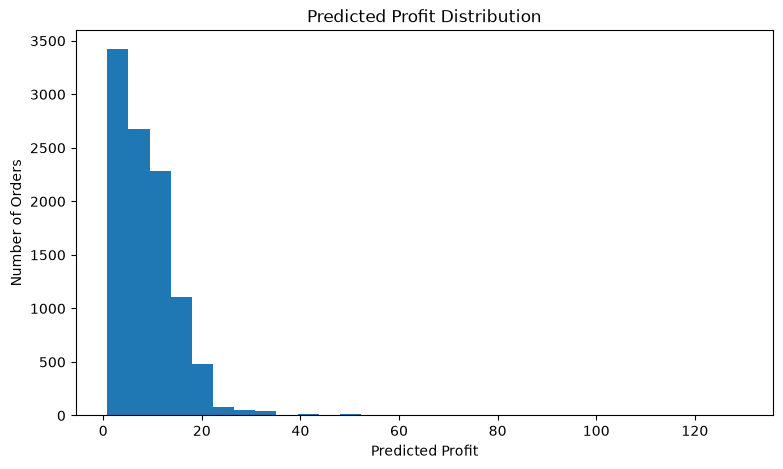

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.hist(
    df["Predicted Profit"],
    bins=30
)

plt.title("Predicted Profit Distribution")
plt.xlabel("Predicted Profit")
plt.ylabel("Number of Orders")

plt.show()

## Regional Profit Analysis

This analysis evaluates the average predicted profit across different regions.

It helps management identify the most profitable factory regions for future production planning.

In [23]:
regional_profit = (
    df.groupby("Region")["Predicted Profit"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

print("Average Predicted Profit by Region")
regional_profit

Average Predicted Profit by Region


,Region,Predicted Profit
0,Pacific,9.367697
1,Interior,9.104591
2,Gulf,9.077655
3,Atlantic,9.051993


## Shipping Mode Performance

Different shipping methods affect business profitability.

This analysis identifies which shipping mode delivers the highest predicted profit.

In [24]:
shipping_profit = (
    df.groupby("Ship Mode")["Predicted Profit"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

print("Average Predicted Profit by Ship Mode")
shipping_profit

Average Predicted Profit by Ship Mode


,Ship Mode,Predicted Profit
0,Second Class,9.264847
1,Standard Class,9.218995
2,First Class,9.047526
3,Same Day,8.604098


## Sales Category Performance

The profitability of orders also depends on their sales category.

Understanding category-level performance supports better inventory allocation.

In [25]:
category_profit = (
    df.groupby("Sales Category")["Predicted Profit"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

print("Average Predicted Profit by Sales Category")
category_profit

Average Predicted Profit by Sales Category


,Sales Category,Predicted Profit
0,High,16.170227
1,Medium,7.842841
2,Low,4.014135


# Executive Recommendation Summary

The optimization engine evaluates every manufacturing order using the trained machine learning model and predicts its expected profitability.

Based on the optimization analysis, management can prioritize production resources toward the highest-value opportunities while minimizing low-return operations.

The following recommendations summarize the overall business findings.

In [26]:
print("="*70)
print("FACTORY OPTIMIZATION RECOMMENDATIONS")
print("="*70)

print()

print("Best Performing Region:")
print(regional_profit.iloc[0]["Region"])

print()

print("Best Shipping Mode:")
print(shipping_profit.iloc[0]["Ship Mode"])

print()

print("Highest Profit Sales Category:")
print(category_profit.iloc[0]["Sales Category"])

print()

print("Average Predicted Profit:")
print(round(df["Predicted Profit"].mean(),2))

print()

print("Highest Predicted Profit:")
print(round(df["Predicted Profit"].max(),2))

print()

print("Lowest Predicted Profit:")
print(round(df["Predicted Profit"].min(),2))

print()

print("Top Recommended Order")

display(
optimization_df[
[
"Order ID",
"Region",
"Ship Mode",
"Sales Category",
"Predicted Profit"
]
].head(1)
)

FACTORY OPTIMIZATION RECOMMENDATIONS

Best Performing Region:
Pacific

Best Shipping Mode:
Second Class

Highest Profit Sales Category:
High

Average Predicted Profit:
9.17

Highest Predicted Profit:
129.45

Lowest Predicted Profit:
0.83

Top Recommended Order


,Order ID,Region,Ship Mode,Sales Category,Predicted Profit
0,US-2021-122336-OTH-LIC-15000,Atlantic,Second Class,High,129.449519


# Conclusion

A complete machine learning optimization pipeline was successfully developed for factory resource allocation.

The Gradient Boosting model accurately predicts expected order profitability and enables intelligent business decision-making.

The optimization engine provides actionable recommendations by identifying:

- the most profitable regions,
- the best shipping methods,
- the highest-value sales categories,
- and the top manufacturing orders.

These insights help management maximize expected profit while improving operational efficiency and production planning.